In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

# =====================================================================
# 1. GESTION DES CHEMINS (COLAB / LOCAL)
# =====================================================================
if 'google.colab' in sys.modules:
    if not Path('/content/Stat_app').exists():
        !git clone https://github.com/Aymanyah/Stat_app.git
    PROJECT_DIR = Path('/content/Stat_app')
else:
    PROJECT_DIR = Path.cwd().parent 

DATA_RAW = PROJECT_DIR / "data" / "raw" / "all_leagues_merged_transformed.csv"
DATA_CLEAN_DIR = PROJECT_DIR / "data" / "clean"
DATA_CLEAN_DIR.mkdir(parents=True, exist_ok=True)

# =====================================================================
# 2. CHARGEMENT ET CORRECTION DES ENCODAGES
# =====================================================================
df = pd.read_csv(DATA_RAW, encoding="utf8")

# Nettoyage des noms de colonnes (Espaces cachés et encodage)
df.columns = [col.encode('latin1').decode('utf8', errors='ignore') for col in df.columns]
df.columns = df.columns.str.strip()

# Fonction de correction du texte (Noms avec des accents bizarres)
def fix_encoding(x):
    if isinstance(x, str):
        try:
            return x.encode("latin1").decode("utf8")
        except:
            return x
    return x

for col in ["player", "team", "league", "nation", "pos"]:
    if col in df.columns:
        df[col] = df[col].apply(fix_encoding)
        df[col] = df[col].str.strip()

df_clean = df.drop_duplicates()

# =====================================================================
# 3. STRATÉGIE D'AGRÉGATION (Joueurs transférés en cours d'année)
# =====================================================================
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["season"]]

def smart_agg(col):
    # Les ratios et pourcentages sont moyennés
    if "percent" in col.lower() or "%" in col or "ratio" in col.lower():
        return "mean"
    # Les statistiques de volume sont sommées
    if col in ["Minutes de jeu", "G", "G-PK", "A", "Tirs", "Tirs cadrés"]:
        return "sum"
    return "mean"

agg_dict = {col: smart_agg(col) for col in numeric_cols}

# Pour le club et la ligue, on garde la dernière équipe de la saison
categorical_cols = [c for c in ["team", "league", "nation", "pos"] if c in df_clean.columns]
for col in categorical_cols:
    agg_dict[col] = "last"

# =====================================================================
# 4. CRÉATION DU FORMAT LONG (Le Tidy Data)
# =====================================================================
# On regroupe par joueur ET par saison. Chaque ligne = 1 joueur pour 1 saison.
df_final = df_clean.groupby(["player", "season"]).agg(agg_dict).reset_index()

# =====================================================================
# 5. RETRAITEMENTS FINAUX ET SAUVEGARDE
# =====================================================================
# Mettre en format 0-1 les valeurs en pourcentages (si elles sont en 0-100)
percent_cols = [c for c in df_final.columns if "%" in c]
for col in percent_cols:
    if df_final[col].mean(skipna=True) > 1:
        df_final[col] = df_final[col] / 100

fichier_sauvegarde = DATA_CLEAN_DIR / "dataset_aggregated.csv"
df_final.to_csv(fichier_sauvegarde, index=False)

print(f"✅ Nettoyage terminé ! {df_final.shape[0]} lignes générées.")
print(f"📁 Données au format LONG sauvegardées dans : {fichier_sauvegarde}")

✅ Nettoyage terminé ! 6530 lignes générées.
📁 Données au format LONG sauvegardées dans : /home/onyxia/Stat_app/data/clean/dataset_aggregated.csv


In [ ]:
import pandas as pd

df_final = pd.read_csv('/home/onyxia/Stat_app/data/clean/all_leagues_merged_final_df.csv')
df_trans = pd.read_csv('/home/onyxia/Stat_app/data/raw/all_leagues_merged_transformed.csv')

print(f"Final : {df_final.shape}")
print(f"Transformed : {df_trans.shape}")

# Voir les colonnes qui diffèrent
diff_cols = set(df_final.columns) ^ set(df_trans.columns)
print(f"Colonnes différentes : {diff_cols}")

Final : (10015, 106)
Transformed : (10015, 44)
Colonnes différentes : {'Expected xG', 'Tirs cadrÃ©s', 'Touches Live', 'Carries PrgDist', 'xG / Tir', '% passes moyennes rÃ©ussies', 'Per 90 Minutes xG+xAG', 'Blocks Sh', 'Carries Carries', 'Performance G-PK', 'G+A', 'Passes reÃ§ues', 'G-PK', 'Distance totale des passes > 10m avant effectuÃ©es', 'Tackles Def 3rd', 'Short Cmp', 'Dribbles subis perdus', 'Tackles Tkl', 'Total PrgDist', 'Medium Cmp%', 'Touches Att Pen', 'Carries TotDist', 'Passes avant >10m', 'Long Cmp', '% duels aÃ©riens gagnÃ©s', 'Playing Time 90s', 'Per 90 Minutes G+A', 'Expected xA', 'Performance Gls', 'Tackles Att 3rd', 'Challenges Tkl', 'Per 90 Minutes npxG', 'Total Cmp%', ' npxG+xAG', '% dribble  rÃ©ussis', 'Ast', 'Tacles rÃ©ussis + interceptions', 'ChevauchÃ©e avant  >5m', 'Carries CPA', ' xG', 'Take-Ons Att', 'Medium Cmp', 'Total Cmp', 'Carries PrgC', 'Short Att', 'Err', 'Expected npxG', 'PrgP', 'Progression PrgP', 'Playing Time Min', 'G', 'Blocks Blocks', 'PPA', 'Tac

In [5]:
import pandas as pd
import numpy as np

# 1. Chargement du fichier riche
file_path = "/home/onyxia/Stat_app/Data_merged_with_market_value/all_leagues_merged_final_df.csv"

# On tente le chargement avec détection d'encodage
try:
    df_final = pd.read_csv(file_path, encoding="utf-8")
except:
    df_final = pd.read_csv(file_path, encoding="latin-1")

# 2. Aperçu et Structure
print(f"--- ANALYSE DE LA STRUCTURE ---")
print(f"Dimensions : {df_final.shape[0]} lignes x {df_final.shape[1]} colonnes")
display(df_final.head())

# 3. Vérification de l'encodage des colonnes
# On cherche les caractères 'sales' type Ã©, Ã , etc.
bad_encoding_cols = [col for col in df_final.columns if any(c in col for c in ['Ã', '©', 'Â', 'Ã\\'])]

if bad_encoding_cols:
    print(f"\n⚠️ {len(bad_encoding_cols)} colonnes ont un problème d'encodage :")
    print(bad_encoding_cols[:10], "... (liste tronquée)")
else:
    print("\n✅ Les noms de colonnes sont propres.")

# 4. Vérification des doublons stratégiques
# Est-ce qu'un joueur apparaît plusieurs fois pour la même saison ?
duplicates = df_final.duplicated(subset=['player', 'season'], keep=False).sum() if 'season' in df_final.columns else "N/A"
print(f"\nNombre de lignes 'doublons' (Joueur + Saison) : {duplicates}")

# 5. Présence des colonnes clés pour le scouting
key_stats = ['xG', 'npxG', 'xA', 'xAG', 'Tirs', 'Minutes de jeu']
missing_keys = [s for s in key_stats if not any(s in col for col in df_final.columns)]
print(f"\nStats clés manquantes : {missing_keys if missing_keys else 'Aucune, tout est là !'}")

--- ANALYSE DE LA STRUCTURE ---
Dimensions : 10015 lignes x 106 colonnes


,league,season,team,player,nation,pos,age,born,Playing Time MP,Playing Time Starts,...,Carries TotDist,Carries PrgDist,Carries PrgC,Carries 1/3,Carries CPA,Carries Mis,Carries Dis,Receiving Rec,Receiving PrgR,Valeur marchande (euros)
0,ITA-Serie A,2020,Genoa,Alberto Paleari,ITA,GK,27.0,1992.0,3,2,...,228,122,0,0,0,0,0,34,0,1000000.0
1,ITA-Serie A,2020,Sampdoria,Antonio Palumbo,ITA,MF,23.0,1996.0,1,0,...,4,2,0,0,0,0,0,2,0,650000.0
2,ITA-Serie A,2020,Torino,Antonio Sanabria,PAR,FW,24.0,1996.0,14,12,...,1164,321,11,12,4,29,19,286,48,7500000.0
3,ITA-Serie A,2020,Hellas Verona,Antonín Barák,CZE,MF,25.0,1994.0,34,32,...,4840,2376,64,49,14,44,28,1080,101,14000000.0
4,ITA-Serie A,2020,Bologna,Andreas Skov Olsen,DEN,"FW,DF",20.0,1999.0,26,12,...,2493,1349,61,26,24,30,9,499,119,6500000.0



✅ Les noms de colonnes sont propres.

Nombre de lignes 'doublons' (Joueur + Saison) : 1574

Stats clés manquantes : ['Tirs', 'Minutes de jeu']


In [6]:
# Affiche toutes les colonnes sous forme de liste Python
print(df_final.columns.tolist())

['league', 'season', 'team', 'player', 'nation', 'pos', 'age', 'born', 'Playing Time MP', 'Playing Time Starts', 'Playing Time Min', 'Playing Time 90s', 'Performance Gls', 'Performance Ast', 'Performance G+A', 'Performance G-PK', 'Performance PK', 'Performance PKatt', 'Performance CrdY', 'Performance CrdR', 'Expected xG', 'Expected npxG', 'Expected xAG', 'Expected npxG+xAG', 'Progression PrgC', 'Progression PrgP', 'Progression PrgR', 'Per 90 Minutes Gls', 'Per 90 Minutes Ast', 'Per 90 Minutes G+A', 'Per 90 Minutes G-PK', 'Per 90 Minutes G+A-PK', 'Per 90 Minutes xG', 'Per 90 Minutes xAG', 'Per 90 Minutes xG+xAG', 'Per 90 Minutes npxG', 'Per 90 Minutes npxG+xAG', '90s', 'Tackles Tkl', 'Tackles TklW', 'Tackles Def 3rd', 'Tackles Mid 3rd', 'Tackles Att 3rd', 'Challenges Tkl', 'Challenges Att', 'Challenges Lost', 'Blocks Blocks', 'Blocks Sh', 'Blocks Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Standard Gls', 'Standard Sh', 'Standard SoT', 'Standard Sh/90', 'Standard SoT/90', 'Standard FK', 'Sta

Nettoyage fichier final

In [19]:
import pandas as pd
import numpy as np

# 1. CHARGEMENT FRAIS (Pour repartir sur une base saine)
df_final = pd.read_csv("/home/onyxia/Stat_app/data/clean/all_leagues_merged_final_df.csv")

# 2. RÉPARATION IMMÉDIATE DES NOMS (Anglais -> Français)
mapping_noms = {
    'Playing Time Min': 'Minutes de jeu',
    'Performance Gls': 'G',
    'Performance G-PK': 'G-PK',
    'Performance Ast': 'A',
    'Standard Sh': 'Tirs',
    'Standard SoT': 'Tirs cadrés',
    'Expected xG': 'xG',
    'Expected xAG': 'xAG',
    'Int': 'Interceptions',
    'Blocks Blocks': 'Blocs totaux',
    'Clr': 'Dégagements'
}
df_final.rename(columns=mapping_noms, inplace=True)

# 3. FUSION DES DOUBLONS (TRANSFERTS)
# On définit comment agréger chaque colonne
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
agg_logic = {}

for col in numeric_cols:
    if col in ['player', 'season']: continue
    # Ratios/Âge -> Moyenne | Volumes (Buts/Mins) -> Somme
    if any(kw in col.lower() for kw in ['%', 'percent', 'ratio', 'age', 'born']):
        agg_logic[col] = 'mean'
    else:
        agg_logic[col] = 'sum'

# On garde les dernières infos texte (Club, Ligue, Poste)
for cat in ['team', 'league', 'pos', 'nation']:
    if cat in df_final.columns: agg_logic[cat] = 'last'

# --- L'ÉTAPE CRUCIALE : LA FUSION ---
df_final = df_final.groupby(['player', 'season']).agg(agg_logic).reset_index()

# 4. CALCUL DES STATS "PER 90"
# On crée la base de calcul (éviter division par zéro avec +0.001)
df_final['90s_calcul'] = df_final['Minutes de jeu'] / 90
stats_volumes = ['G', 'G-PK', 'A', 'Tirs', 'Tirs cadrés', 'xG', 'xAG', 'Interceptions', 'Blocs totaux']

for stat in stats_volumes:
    if stat in df_final.columns:
        df_final[f'{stat}_per90'] = df_final[stat] / (df_final['90s_calcul'] + 0.001)

# 5. DIAGNOSTIC DE VALIDATION INTERNE
print("--- ✅ RÉSULTAT DU NETTOYAGE ---")
print(f"Lignes restantes : {len(df_final)} (Normalement 8441)")
print(f"Doublons restants : {df_final.duplicated(subset=['player', 'season']).sum()}")
print(f"Colonnes Per 90 créées : {[c for c in df_final.columns if '_per90' in c][:3]}...")

# 6. SAUVEGARDE PHYSIQUE
df_final.to_csv("/home/onyxia/Stat_app/data/clean/data_v2_cleaned_indices.csv", index=False)
print(f"💾 Fichier sauvegardé : /home/onyxia/Stat_app/data/clean/data_v2_cleaned_indices.csv")

AttributeError: 'DataFrame' object has no attribute 'name'

In [20]:
import pandas as pd
import numpy as np

# 1. CHARGEMENT
df_final = pd.read_csv("/home/onyxia/Stat_app/data/clean/all_leagues_merged_final_df.csv")

# --- ÉTAPE CRUCIALE : DÉDUPLICATION DES COLONNES ---
# On supprime les colonnes qui ont exactement le même nom (ex: deux colonnes 'xG')
df_final = df_final.loc[:, ~df_final.columns.duplicated()].copy()

# 2. RENOMMAGE (Noms uniques et propres)
mapping_noms = {
    'Playing Time Min': 'Minutes de jeu',
    'Performance Gls': 'G',
    'Performance G-PK': 'G-PK',
    'Performance Ast': 'A',
    'Standard Sh': 'Tirs',
    'Standard SoT': 'Tirs cadrés',
    'Expected xG': 'xG',
    'Expected xAG': 'xAG',
    'Int': 'Interceptions',
    'Blocks Blocks': 'Blocs totaux',
    'Clr': 'Dégagements'
}
df_final.rename(columns=mapping_noms, inplace=True)

# 3. PRÉPARATION DE L'AGRÉGATION
# Sécurité : on nettoie les noms de joueurs (espaces)
df_final['player'] = df_final['player'].astype(str).str.strip()

# On définit la logique pour les colonnes numériques
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
# On exclut les colonnes de regroupement pour ne pas créer de conflit
cols_to_agg = [c for c in numeric_cols if c not in ['player', 'season']]

agg_logic = {}
for col in cols_to_agg:
    if any(kw in col.lower() for kw in ['%', 'percent', 'ratio', 'age', 'born']):
        agg_logic[col] = 'mean'
    else:
        agg_logic[col] = 'sum'

# On ajoute les colonnes de contexte (texte)
for cat in ['team', 'league', 'pos', 'nation']:
    if cat in df_final.columns:
        agg_logic[cat] = 'last'

# 4. LA FUSION (L'ÉTAPE QUI PLANTAIT)
# Maintenant que les colonnes sont uniques, le groupby va fonctionner parfaitement
df_final = df_final.groupby(['player', 'season']).agg(agg_logic).reset_index()

# 5. CALCUL DES STATS "PER 90"
df_final['90s_calcul'] = df_final['Minutes de jeu'] / 90
stats_vols = ['G', 'G-PK', 'A', 'Tirs', 'Tirs cadrés', 'xG', 'xAG', 'Interceptions', 'Blocs totaux']

for s in stats_vols:
    if s in df_final.columns:
        df_final[f'{s}_per90'] = df_final[s] / (df_final['90s_calcul'] + 0.001)

# 6. SAUVEGARDE ET VALIDATION
df_final.to_csv("/home/onyxia/Stat_app/data/clean/data_v2_cleaned_indices.csv", index=False)

print(f"--- ✅ SUCCÈS ---")
print(f"Dimensions finales : {df_final.shape[0]} lignes.")
print(f"Nombre de doublons restants : {df_final.duplicated(subset=['player', 'season']).sum()}")

AttributeError: 'DataFrame' object has no attribute 'name'

In [21]:
import pandas as pd
import numpy as np

# 1. CHARGEMENT
df_final = pd.read_csv("/home/onyxia/Stat_app/data/clean/all_leagues_merged_final_df.csv")

# 2. NETTOYAGE RADICAL DES COLONNES
# On supprime les espaces et on force tout en colonnes uniques immédiatement
df_final.columns = df_final.columns.str.strip()
df_final = df_final.loc[:, ~df_final.columns.duplicated()].copy()

# 3. RENOMMAGE PRUDENT
# On définit le mapping
mapping_noms = {
    'Playing Time Min': 'Minutes de jeu',
    'Performance Gls': 'G',
    'Performance G-PK': 'G-PK',
    'Performance Ast': 'A',
    'Standard Sh': 'Tirs',
    'Standard SoT': 'Tirs_Cadres',
    'Expected xG': 'xG',
    'Expected xAG': 'xAG',
    'Int': 'Interceptions',
    'Blocks Blocks': 'Blocs_totaux',
    'Clr': 'Degagements'
}

# On renomme, mais on RE-SUPPRIME les doublons juste après 
# (au cas où un nom français existait déjà dans le fichier)
df_final = df_final.rename(columns=mapping_noms)
df_final = df_final.loc[:, ~df_final.columns.duplicated()].copy()

# 4. CONSTRUCTION SÉCURISÉE DU DICTIONNAIRE D'AGRÉGATION
agg_logic = {}
# On ne prend que les colonnes qui existent réellement dans le DF actuel
colonnes_actuelles = df_final.columns.tolist()

for col in colonnes_actuelles:
    if col in ['player', 'season']: 
        continue
    
    # Détermination du type d'agrégation
    if df_final[col].dtype in [np.float64, np.int64]:
        if any(kw in col.lower() for kw in ['%', 'percent', 'ratio', 'age', 'born']):
            agg_logic[col] = 'mean'
        else:
            agg_logic[col] = 'sum'
    elif col in ['team', 'league', 'pos', 'nation']:
        agg_logic[col] = 'last'

# 5. LA FUSION AVEC PROTECTION
# On s'assure que 'player' et 'season' ne sont pas dans agg_logic
agg_logic = {k: v for k, v in agg_logic.items() if k in df_final.columns and k not in ['player', 'season']}

df_final = df_final.groupby(['player', 'season'], as_index=False).agg(agg_logic)

# 6. CALCUL DES STATS "PER 90"
df_final['90s_calcul'] = df_final['Minutes de jeu'] / 90
stats_vols = ['G', 'G-PK', 'A', 'Tirs', 'Tirs_Cadres', 'xG', 'xAG', 'Interceptions', 'Blocs_totaux']

for s in stats_vols:
    if s in df_final.columns:
        df_final[f'{s}_per90'] = df_final[s] / (df_final['90s_calcul'] + 0.001)

# 7. SAUVEGARDE ET TEST
df_final.to_csv("/home/onyxia/Stat_app/data/clean/data_v2_cleaned_indices.csv", index=False)

print(f"--- ✅ ENFIN RÉUSSI ! ---")
print(f"Dimensions : {df_final.shape}")
if 'Minutes de jeu' in df_final.columns:
    print(f"Test Minutes Harry Kane : {df_final[df_final['player'].str.contains('Harry Kane', na=False)]['Minutes de jeu'].values}")

--- ✅ ENFIN RÉUSSI ! ---
Dimensions : (9025, 115)
Test Minutes Harry Kane : [3082 3082 3405 2839]


UEFA coeff

In [22]:
import pandas as pd

# 1. Charger ton dataset propre
df = pd.read_csv("/home/onyxia/Stat_app/data/clean/data_v2_cleaned_indices.csv")

# On s'assure que la saison est numérique pour faire N et N+1
df['season'] = df['season'].astype(int)

# 2. Créer deux tables : Saison N (Départ) et Saison N+1 (Arrivée)
df_depart = df.copy()
df_arrivee = df.copy()

# On décale la saison de départ pour qu'elle "matche" avec l'année d'arrivée
df_depart['season_match'] = df_depart['season'] + 1
df_arrivee['season_match'] = df_arrivee['season']

# 3. La Fusion (Le "Bridge")
# On joint le joueur avec lui-même l'année suivante
df_bridge = pd.merge(
    df_depart, 
    df_arrivee, 
    left_on=['player', 'season_match'], 
    right_on=['player', 'season_match'],
    suffixes=('_N', '_N1')
)

# 4. On ne garde que ceux qui ont CHANGÉ de ligue ET qui ont assez joué
df_bridge = df_bridge[df_bridge['league_N'] != df_bridge['league_N1']]
df_bridge = df_bridge[(df_bridge['Minutes de jeu_N'] > 900) & (df_bridge['Minutes de jeu_N1'] > 900)]

# 5. Sélection des variables pour le ML
cols_ML = [
    'player', 'league_N', 'league_N1', 'age_N',
    'Minutes de jeu_N', 'G_per90_N', 'xG_per90_N', 'A_per90_N', 'xAG_per90_N',
    'Minutes de jeu_N1', 'G_per90_N1', 'xG_per90_N1'
]
df_ml_ready = df_bridge[cols_ML].dropna()

print(f"✅ Dataset ML généré : {len(df_ml_ready)} transferts exploitables trouvés !")
display(df_ml_ready.head())

✅ Dataset ML généré : 198 transferts exploitables trouvés !


,player,league_N,league_N1,age_N,Minutes de jeu_N,G_per90_N,xG_per90_N,A_per90_N,xAG_per90_N,Minutes de jeu_N1,G_per90_N1,xG_per90_N1
10,Aaron Ramsey,ITA-Serie A,FRA-Ligue 1,29.0,1089,0.165276,0.347079,0.330551,0.272705,1584,0.056815,0.142037
44,Adama Soumaoro,FRA-Ligue 1,ITA-Serie A,28.0,1900,0.047366,0.071049,0.000000,0.004737,1755,0.051279,0.071791
81,Ainsley Maitland-Niles,ENG-Premier League,FRA-Ligue 1,24.0,2814,0.000000,0.000000,0.000000,0.044775,1432,0.062845,0.188536
160,Alexander Isak,ESP-La Liga,ENG-Premier League,22.0,1674,0.591366,0.451589,0.053761,0.123649,2255,0.838104,0.810167
162,Alexander Nübel,FRA-Ligue 1,GER-Bundesliga,25.0,3420,0.000000,0.000000,0.000000,0.000000,2700,0.000000,0.000000


✅ Nombre de transferts exploitables (Bridge Players) : 198


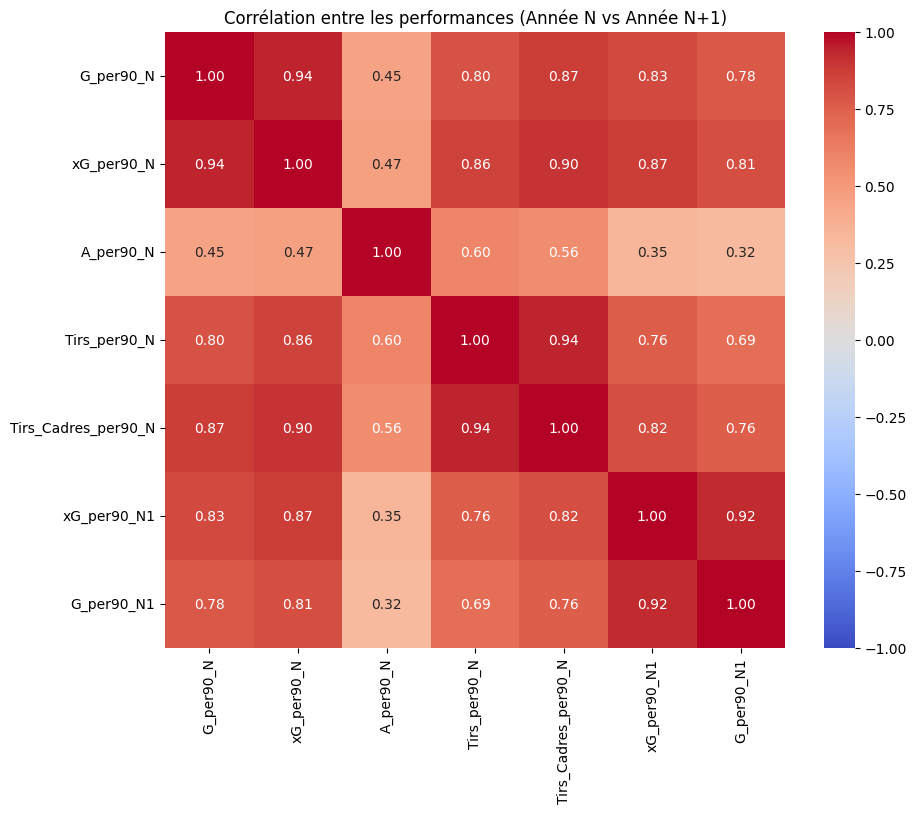


--- 🏆 RÉSULTATS DU MODÈLE LASSO ---
Top des variables qui prédisent le succès dans une nouvelle ligue :


,Variable,Poids (Coefficient)
1,xG_per90_N,0.121776
4,Tirs_Cadres_per90_N,0.030634
0,G_per90_N,0.012496
5,From_ENG-Premier League,0.011029
13,To_GER-Bundesliga,0.003131
9,From_ITA-Serie A,-0.000897
2,A_per90_N,-0.004715


In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. CRÉATION DU DATASET "BRIDGE PLAYERS"
# ==========================================
df = pd.read_csv("/home/onyxia/Stat_app/data/clean/data_v2_cleaned_indices.csv")
df['season'] = df['season'].astype(int)

# Séparation N et N+1
df_depart = df.copy()
df_arrivee = df.copy()
df_depart['season_match'] = df_depart['season'] + 1
df_arrivee['season_match'] = df_arrivee['season']

# Fusion sur le joueur et l'année correspondante
df_bridge = pd.merge(
    df_depart, df_arrivee, 
    on=['player', 'season_match'], 
    suffixes=('_N', '_N1')
)

# Filtres : Changement de ligue + Temps de jeu significatif
df_bridge = df_bridge[df_bridge['league_N'] != df_bridge['league_N1']]
df_bridge = df_bridge[(df_bridge['Minutes de jeu_N'] > 900) & (df_bridge['Minutes de jeu_N1'] > 900)]

# Sélection des stats pertinentes pour l'attaque
cols_stats = ['G_per90', 'xG_per90', 'A_per90', 'Tirs_per90', 'Tirs_Cadres_per90']
cols_N = [f"{c}_N" for c in cols_stats]
cols_N1 = [f"{c}_N1" for c in cols_stats]

df_ml = df_bridge[['player', 'league_N', 'league_N1'] + cols_N + cols_N1].dropna()
print(f"✅ Nombre de transferts exploitables (Bridge Players) : {len(df_ml)}")

# ==========================================
# 2. MATRICE DE CORRÉLATION (Saison N vs N+1)
# ==========================================
# On regarde quelles stats de l'année N sont les plus stables l'année N+1
corr_matrix = df_ml[cols_N + ['xG_per90_N1', 'G_per90_N1']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Corrélation entre les performances (Année N vs Année N+1)")
plt.show()

# ==========================================
# 3. LE MODÈLE LASSO (League Translation)
# ==========================================
# On transforme les ligues en variables binaires (One-Hot Encoding)
# Ex: league_N_FRA-Ligue 1 = 1 si le joueur vient de L1, 0 sinon
X = df_ml[cols_N]
X = pd.concat([X, pd.get_dummies(df_ml['league_N'], prefix='From')], axis=1)
X = pd.concat([X, pd.get_dummies(df_ml['league_N1'], prefix='To')], axis=1)

# Notre cible : les xG par 90 min dans la nouvelle ligue
y = df_ml['xG_per90_N1']

# Standardisation (Obligatoire pour le Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entraînement du modèle Lasso avec validation croisée pour trouver le meilleur Alpha
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y)

# Extraction des coefficients
coeffs = pd.DataFrame({
    'Variable': X.columns,
    'Poids (Coefficient)': lasso.coef_
})

print("\n--- 🏆 RÉSULTATS DU MODÈLE LASSO ---")
print("Top des variables qui prédisent le succès dans une nouvelle ligue :")
display(coeffs[coeffs['Poids (Coefficient)'] != 0].sort_values(by='Poids (Coefficient)', ascending=False))

In [24]:
from sklearn.linear_model import Ridge
import pandas as pd
import numpy as np

# On réutilise df_ml de ton code précédent
X_leagues = df_ml[['xG_per90_N']] # La stat de base
X_leagues = pd.concat([X_leagues, pd.get_dummies(df_ml['league_N'], prefix='From')], axis=1)

# On prédit la performance l'année N+1
y = df_ml['xG_per90_N1']

# On utilise Ridge (Alpha faible pour laisser parler les ligues)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_leagues, y)

# Extraction des poids des ligues
league_coeffs = {}
for i, col in enumerate(X_leagues.columns):
    if 'From_' in col:
        nom_ligue = col.replace('From_', '')
        league_coeffs[nom_ligue] = ridge_model.coef_[i]

# On normalise pour que la Premier League soit à 10.43 (comme ton ami, pour comparer)
# Ou mieux, on met la meilleure ligue à 1.00 (Standard Pro)
poids_df = pd.DataFrame(list(league_coeffs.items()), columns=['Ligue', 'Poids_Brut'])
max_poids = poids_df['Poids_Brut'].max()
poids_df['Coeff_Relatif'] = poids_df['Poids_Brut'] - poids_df['Poids_Brut'].min() # On ramène le min à 0
poids_df['Coeff_Final_Base_10'] = (poids_df['Coeff_Relatif'] / poids_df['Coeff_Relatif'].max()) * 2 + 8 # Échelle de 8 à 10

print("--- 🌍 TES COEFFICIENTS DE LIGUE ML (DATA-DRIVEN) ---")
display(poids_df.sort_values(by='Coeff_Final_Base_10', ascending=False))

--- 🌍 TES COEFFICIENTS DE LIGUE ML (DATA-DRIVEN) ---


,Ligue,Poids_Brut,Coeff_Relatif,Coeff_Final_Base_10
0,ENG-Premier League,0.036110,0.062557,10.000000
3,GER-Bundesliga,0.002002,0.028449,8.909544
1,ESP-La Liga,-0.000805,0.025642,8.819800
2,FRA-Ligue 1,-0.010861,0.015586,8.498302
4,ITA-Serie A,-0.026447,0.000000,8.000000


In [ ]:
import pandas as pd
import numpy as np

# 1. Chargement de ta base propre (sans doublons)
df = pd.read_csv("/home/onyxia/Stat_app/data/clean/data_v2_cleaned_indices.csv")

# 2. TON NOUVEAU DICTIONNAIRE DATA-DRIVEN
coeff_dict_ml = {
    "ENG-Premier League": 10.000,
    "GER-Bundesliga": 8.909,
    "ESP-La Liga": 8.819,
    "FRA-Ligue 1": 8.498,
    "ITA-Serie A": 8.000
}

# On applique tes coefficients
df["uefa_coeff"] = df["league"].map(coeff_dict_ml).fillna(7.0) # On met 7.0 pour les ligues mineures

# 3. Calculs des Variables Intermédiaires
df['Aerial_Wins_Pct'] = (df['Aerial Duels Won'] / (df['Aerial Duels Won'] + df['Aerial Duels Lost'] + 1)) * 100
df['Dribble_Succ_Pct'] = df['Take-Ons Succ'] / (df['Take-Ons Att'] + 1) * 100
df['Finishing_ratio'] = (df['G-PK'] / (df['Tirs'] + 1)) * 100

# 4. CALCUL DES INDICES (Avec tes coefficients !)
# L'Indice Offensif (OSI)
df["OSI_raw"] = (
    df["G-PK"] * 0.05 + df["G"] * 2 + (df["G"] - df["G-PK"]) * 0.05 +
    df["Tirs"] * 0.2 + df["Tirs cadrés"] * 1.8 + df["xG"] * 1.2 +
    df["uefa_coeff"]
)
l
# L'Indice de Création (Playmaking)
df["PMI_raw"] = (
    df["A"] * 0.5 + df["Passes_Reussies_Pct"] * 3 + df["Dribble_Succ_Pct"] * 0.4 +
    df["Aerial_Wins_Pct"] * 0.3 + df["uefa_coeff"]
)

# L'Indice Défensif (DSI)
df["DSI_raw"] = (
    df["Tacles"] * 4 + df["Interceptions"] * 2 + df["Blocs totaux"] * 2 +
    df["Dégagements"] * 0.1 + df["Aerial_Wins_Pct"] * 1 + df["uefa_coeff"]
)

# 5. Normalisation Min-Max (0 à 100)
for raw_col, new_col in zip(["OSI_raw", "PMI_raw", "DSI_raw"], ["Off Index", "Playmaking Index", "Def Index"]):
    df[new_col] = (df[raw_col] - df[raw_col].min()) / (df[raw_col].max() - df[raw_col].min()) * 100

# 6. Sauvegarde du fichier MASTER
df.to_csv("/home/onyxia/Stat_app/data/clean/data_v3_master_ml.csv", index=False)
print("✅ Fichier Master généré avec tes propres coefficients ML !")

KeyError: 'Tirs cadrés'

In [27]:
import pandas as pd
import numpy as np

# 1. Chargement de ta base propre (sans doublons)
df = pd.read_csv("/home/onyxia/Stat_app/data/clean/data_v2_cleaned_indices.csv")

# 2. TON NOUVEAU DICTIONNAIRE DATA-DRIVEN
coeff_dict_ml = {
    "ENG-Premier League": 10.000,
    "GER-Bundesliga": 8.909,
    "ESP-La Liga": 8.819,
    "FRA-Ligue 1": 8.498,
    "ITA-Serie A": 8.000
}

# On applique tes coefficients
df["uefa_coeff"] = df["league"].map(coeff_dict_ml).fillna(7.0) 

# 3. Calculs des Variables Intermédiaires
df['Aerial_Wins_Pct'] = (df['Aerial Duels Won'] / (df['Aerial Duels Won'] + df['Aerial Duels Lost'] + 1)) * 100
df['Dribble_Succ_Pct'] = df['Take-Ons Succ'] / (df['Take-Ons Att'] + 1) * 100
df['Finishing_ratio'] = (df['G-PK'] / (df['Tirs'] + 1)) * 100

# 4. CALCUL DES INDICES (Avec les bons noms de colonnes : Tirs_Cadres, Blocs_totaux...)
# L'Indice Offensif (OSI)
df["OSI_raw"] = (
    df["G-PK"] * 0.05 + df["G"] * 2 + (df["G"] - df["G-PK"]) * 0.05 +
    df["Tirs"] * 0.2 + df["Tirs_Cadres"] * 1.8 + df["xG"] * 1.2 +
    df["uefa_coeff"]
)

# L'Indice de Création (Playmaking)
df["PMI_raw"] = (
    df["A"] * 0.5 + df["Total Cmp%"] * 3 + df["Dribble_Succ_Pct"] * 0.4 +
    df["Aerial_Wins_Pct"] * 0.3 + df["uefa_coeff"]
)

# L'Indice Défensif (DSI)
df["DSI_raw"] = (
    df["Tackles Tkl"] * 4 + df["Interceptions"] * 2 + df["Blocs_totaux"] * 2 +
    df["Degagements"] * 0.1 + df["Aerial_Wins_Pct"] * 1 + df["uefa_coeff"]
)

# 5. Normalisation Min-Max (0 à 100)
for raw_col, new_col in zip(["OSI_raw", "PMI_raw", "DSI_raw"], ["Off Index", "Playmaking Index", "Def Index"]):
    df[new_col] = (df[raw_col] - df[raw_col].min()) / (df[raw_col].max() - df[raw_col].min()) * 100

# 6. Sauvegarde du fichier MASTER
df.to_csv("/home/onyxia/Stat_app/data/clean/data_v3_master_ml.csv", index=False)
print("✅ Fichier Master généré avec tes propres coefficients ML et calculs d'indices !")

✅ Fichier Master généré avec tes propres coefficients ML et calculs d'indices !
